In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Creditcard_data.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (772, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,1
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
print("Missing Values:")
print(df.isnull().sum().sum())

print("\nClass Distribution:")
print(df["Class"].value_counts())

Missing Values:
0

Class Distribution:
Class
0    763
1      9
Name: count, dtype: int64


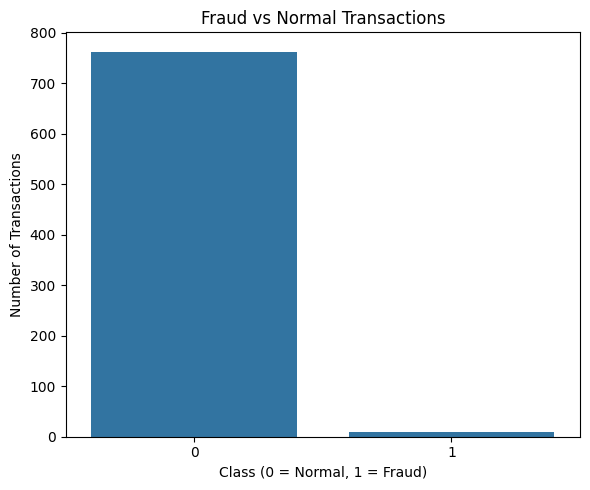

In [4]:
plt.figure(figsize=(6, 5))

sns.countplot(x="Class", data=df)

plt.title("Fraud vs Normal Transactions")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.tight_layout()

plt.savefig("fraud_distribution.png")
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df.drop(columns=["Class"])
y = df["Class"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Scale the features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (617, 30)
Testing data: (155, 30)


In [6]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [7]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Accuracy: 0.9870967741935484

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       153
           1       0.00      0.00      0.00         2

    accuracy                           0.99       155
   macro avg       0.49      0.50      0.50       155
weighted avg       0.97      0.99      0.98       155



C:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

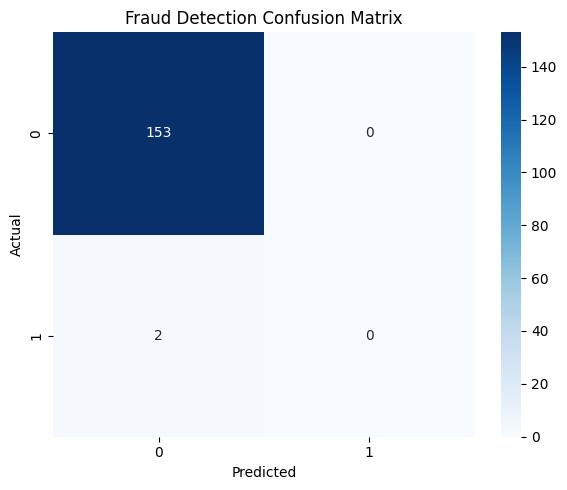

In [8]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    confusion_matrix(y_test, rf_pred),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Fraud Detection Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()

plt.savefig("confusion_matrix.png")
plt.show()

In [9]:
from sklearn.metrics import roc_curve, roc_auc_score

rf_prob = rf_model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, rf_prob)
auc_score = roc_auc_score(y_test, rf_prob)

print("ROC-AUC Score:", round(auc_score, 4))

ROC-AUC Score: 0.6438


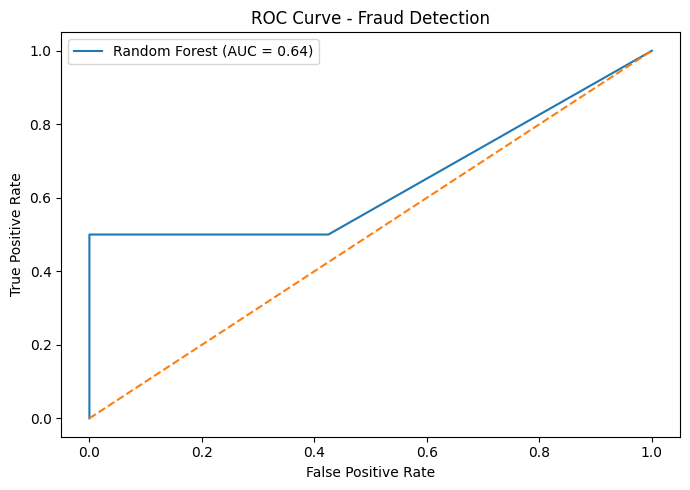

In [10]:
plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve - Fraud Detection")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()

plt.savefig("roc_curve.png")
plt.show()

In [11]:
importance = pd.DataFrame({
    "Feature": df.drop(columns=["Class"]).columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

   Feature  Importance
23     V23    0.120901
29  Amount    0.117549
1       V1    0.095963
10     V10    0.061045
27     V27    0.050075
15     V15    0.045825
20     V20    0.044451
7       V7    0.042265
13     V13    0.033990
24     V24    0.033324


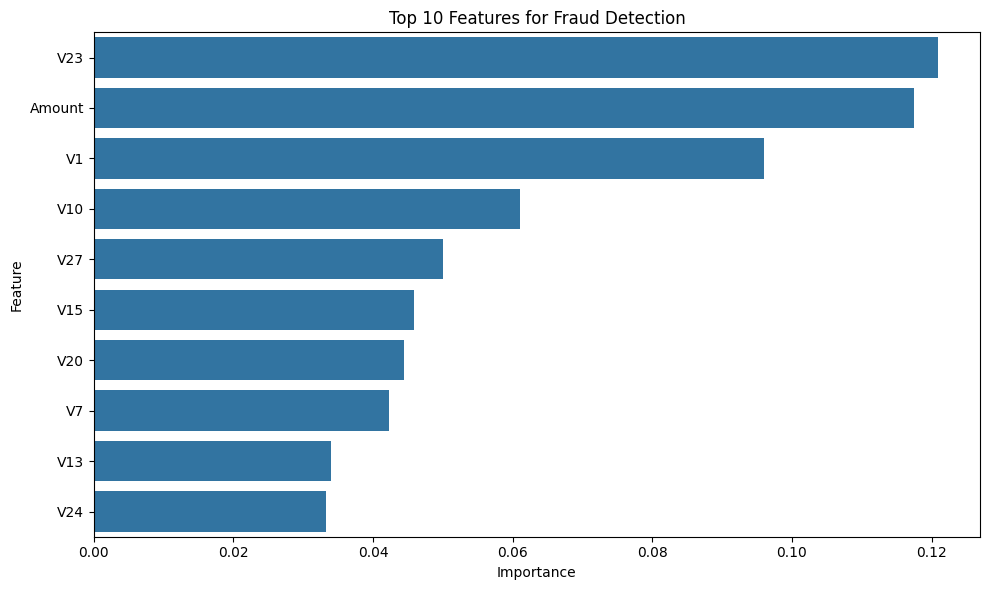

In [13]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance.head(10)
)

plt.title("Top 10 Features for Fraud Detection")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig("feature_importance.png")
plt.show()

In [14]:
print("Fraud Detection Results")
print("-----------------------")
print("Accuracy :", round(accuracy_score(y_test, rf_pred), 4))
print("ROC-AUC  :", round(auc_score, 4))

print("\nModel successfully trained and evaluated.")

Fraud Detection Results
-----------------------
Accuracy : 0.9871
ROC-AUC  : 0.6438

Model successfully trained and evaluated.
